In [50]:
import os
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from safetensors.torch import save_model
from torch import nn, optim

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    create_data_loader,
    get_dataset_class,
)
from nnscaling.visualization import plot_decision_boundary
from nnscaling.log import logger
from nnscaling.models import MLP
from nnscaling.scripts.common import load_config, train_one_epoch
from nnscaling.utils import get_device, set_seed


In [51]:
device = get_device()
seed = 42
batch_size = 256
num_epochs = 2_000
set_seed(seed)

In [52]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="YinYangBinaryDataset",
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)
train_loader = create_data_loader(dataset, batch_size=batch_size, global_seed=seed)

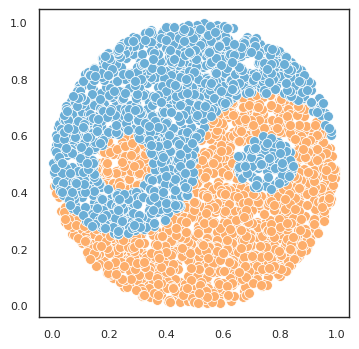

In [53]:
# Figure and plot
fig, ax = plt.subplots()

labels = [0, 1]
colors = [
    aesthetics.SeabornColors.orange,
    aesthetics.SeabornColors.blue,
]
for i, label in enumerate(labels):
    sns.scatterplot(
        x=dataset.features[dataset.labels.squeeze() == label, 0].numpy(),
        y=dataset.features[dataset.labels.squeeze() == label, 1].numpy(),
        ax=ax,
        color=colors[i],
        marker="o",
        s=50,
    )

plt.show()

In [54]:
model = MLP(
    config=[10, 8, 8, 8, 6, 3],
    in_features=dataset.features.shape[-1],
    out_features=2,
    nonlinearity=nn.ReLU,
)
model.to(device)
_ = model.train()
model.summary()

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (_features)                 --
|    + LinearLayer (0)                   --
|    |    + Linear (linear)              30
|    |    + ReLU (activation)            --
|    + LinearLayer (1)                   --
|    |    + Linear (linear)              88
|    |    + ReLU (activation)            --
|    + LinearLayer (2)                   --
|    |    + Linear (linear)              72
|    |    + ReLU (activation)            --
|    + LinearLayer (3)                   --
|    |    + Linear (linear)              72
|    |    + ReLU (activation)            --
|    + LinearLayer (4)                   --
|    |    + Linear (linear)              54
|    |    + ReLU (activation)            --
|    + LinearLayer (5)                   --
|    |    + Linear (linear)              21
|    |    + ReLU (activation)            --
|    + LinearLayer (6)                   --
|    |    + Linear (linear)

In [55]:
# Define loss and optimiser
loss = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

In [ ]:
# Loop over epochs
for epoch in range(num_epochs):
    # Train step
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        device=device,
        criterion=loss,
        optimizer=optimizer,
    )

    # Print loss
    if (epoch + 1) % 100 == 0:
        logger.info(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_loss:.4f}")

# if config.save_dir:
#     metadata_dict = {
#         "config": str(config.hidden_neurons),
#         "dataset": dataset.name(),
#         "out_features": str(config.out_features),
#         "nonlinearity": "relu",
#     }
#     os.makedirs(os.path.dirname(config.save_dir), exist_ok=True)
#     save_model(
#         model,
#         Path(config.save_dir, "yinyang_model.safetensors"),
#         metadata=metadata_dict,
#     )

2024-11-13 10:58:17 - INFO - Epoch 100/2000, Loss: 0.2701
2024-11-13 10:58:23 - INFO - Epoch 200/2000, Loss: 0.2379
2024-11-13 10:58:28 - INFO - Epoch 300/2000, Loss: 0.2345


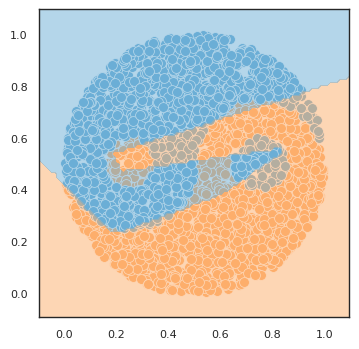

In [ ]:
plot_decision_boundary(
    model,
    model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)